In [1]:
!pip install kaggle

In [2]:
# configuring the path of Kaggle.json file
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
# API to fetch the dataset from Kaggle
!kaggle datasets download -d omkargurav/face-mask-dataset

Dataset URL: https://www.kaggle.com/datasets/omkargurav/face-mask-dataset
License(s): unknown
100% 163M/163M [00:01<00:00, 136MB/s]



In [4]:
# extracting the compessed Dataset
from zipfile import ZipFile
dataset = '/content/face-mask-dataset.zip'

with ZipFile(dataset,'r') as zip:
  zip.extractall()
  print('The dataset is extracted')

The dataset is extracted


In [5]:
!ls

data  face-mask-dataset.zip  kaggle.json  sample_data


In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
from sklearn.model_selection import train_test_split

In [7]:
with_mask_files = os.listdir('/content/data/with_mask')
print(with_mask_files[0:5])
print(with_mask_files[-5:])

['with_mask_794.jpg', 'with_mask_26.jpg', 'with_mask_3120.jpg', 'with_mask_1846.jpg', 'with_mask_496.jpg']
['with_mask_727.jpg', 'with_mask_775.jpg', 'with_mask_206.jpg', 'with_mask_2324.jpg', 'with_mask_321.jpg']


In [8]:
without_mask_files = os.listdir('/content/data/without_mask')
print(without_mask_files[0:5])
print(without_mask_files[-5:])

['without_mask_2396.jpg', 'without_mask_1520.jpg', 'without_mask_44.jpg', 'without_mask_837.jpg', 'without_mask_2052.jpg']
['without_mask_3629.jpg', 'without_mask_1464.jpg', 'without_mask_497.jpg', 'without_mask_152.jpg', 'without_mask_2198.jpg']


In [9]:
print('Number of with mask images:', len(with_mask_files))
print('Number of without mask images:', len(without_mask_files))

Number of with mask images: 3725
Number of without mask images: 3828


In [10]:
# create the labels

with_mask_labels = [1]*3725

without_mask_labels = [0]*3828

In [11]:
print(with_mask_labels[0:5])

print(without_mask_labels[0:5])

[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


In [12]:
print(len(with_mask_labels))
print(len(without_mask_labels))

3725
3828


In [13]:
labels = with_mask_labels + without_mask_labels

print(len(labels))
print(labels[0:5])
print(labels[-5:])

7553
[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


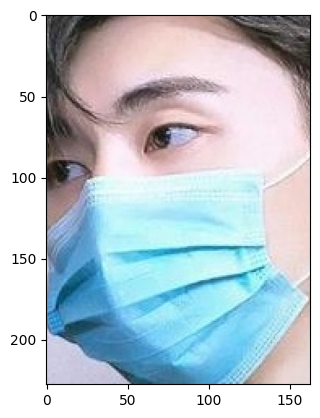

In [14]:
# displaying with mask image
img = mpimg.imread('/content/data/with_mask/with_mask_1545.jpg')
imgplot = plt.imshow(img)
plt.show()

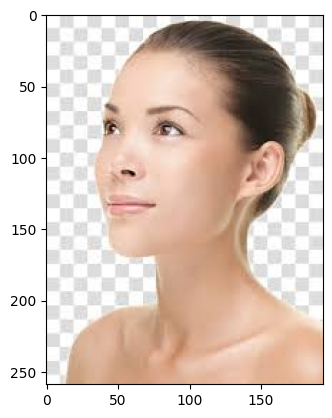

In [15]:
# displaying without mask image
img = mpimg.imread('/content/data/without_mask/without_mask_2925.jpg')
imgplot = plt.imshow(img)
plt.show()

In [16]:
# convert images to numpy arrays+

with_mask_path = '/content/data/with_mask/'

data = []

for img_file in with_mask_files:

  image = Image.open(with_mask_path + img_file)
  image = image.resize((128,128))
  image = image.convert('RGB')
  image = np.array(image)
  data.append(image)



without_mask_path = '/content/data/without_mask/'


for img_file in without_mask_files:

  image = Image.open(without_mask_path + img_file)
  image = image.resize((128,128))
  image = image.convert('RGB')
  image = np.array(image)
  data.append(image)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [17]:
type(data)

list

In [18]:
len(data)

7553

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[ 41,  41,  41],
        [ 42,  42,  42],
        [ 42,  42,  42],
        ...,
        [ 40,  40,  40],
        [ 40,  40,  40],
        [ 40,  40,  40]],

       [[ 42,  42,  42],
        [ 42,  42,  42],
        [ 41,  41,  41],
        ...,
        [ 40,  40,  40],
        [ 40,  40,  40],
        [ 40,  40,  40]],

       [[ 44,  44,  44],
        [ 42,  42,  42],
        [ 40,  40,  40],
        ...,
        [ 40,  40,  40],
        [ 40,  40,  40],
        [ 40,  40,  40]]], dtype=uint8)
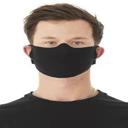

In [19]:
data[0]

In [20]:
type(data[0])

numpy.ndarray

In [21]:
data[0].shape

(128, 128, 3)

In [22]:
# converting image list and label list to numpy arrays

X = np.array(data)
Y = np.array(labels)

In [23]:
print(X.shape)
print(Y.shape)

(7553, 128, 128, 3)
(7553,)


In [24]:
print(Y)

[1 1 1 ... 0 0 0]


In [25]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [26]:
print(X.shape, X_train.shape, X_test.shape)

(7553, 128, 128, 3) (6042, 128, 128, 3) (1511, 128, 128, 3)


In [27]:
# scaling the data

X_train_scaled = X_train/255

X_test_scaled = X_test/255

array([[[ 62,  57,  51],
        [ 72,  67,  61],
        [ 51,  48,  43],
        ...,
        [154, 137, 123],
        [196, 178, 163],
        [218, 199, 183]],

       [[ 59,  55,  50],
        [ 65,  62,  56],
        [ 45,  42,  37],
        ...,
        [105,  91,  81],
        [173, 154, 136],
        [221, 199, 182]],

       [[ 58,  54,  50],
        [ 63,  59,  55],
        [ 43,  40,  35],
        ...,
        [ 72,  62,  56],
        [115, 101,  88],
        [187, 167, 148]],

       ...,

       [[252, 235, 225],
        [252, 236, 227],
        [253, 239, 230],
        ...,
        [254, 205, 209],
        [254, 208, 211],
        [252, 209, 213]],

       [[249, 232, 222],
        [250, 233, 223],
        [250, 232, 222],
        ...,
        [253, 205, 209],
        [252, 207, 211],
        [250, 209, 214]],

       [[249, 231, 220],
        [248, 230, 219],
        [247, 229, 219],
        ...,
        [251, 205, 209],
        [250, 206, 212],
        [248, 208, 215]]], dtype=uint8)
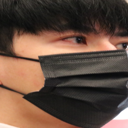

In [28]:
X_train[0]

In [29]:
X_train_scaled[0]

array([[[0.24313725, 0.22352941, 0.2       ],
        [0.28235294, 0.2627451 , 0.23921569],
        [0.2       , 0.18823529, 0.16862745],
        ...,
        [0.60392157, 0.5372549 , 0.48235294],
        [0.76862745, 0.69803922, 0.63921569],
        [0.85490196, 0.78039216, 0.71764706]],

       [[0.23137255, 0.21568627, 0.19607843],
        [0.25490196, 0.24313725, 0.21960784],
        [0.17647059, 0.16470588, 0.14509804],
        ...,
        [0.41176471, 0.35686275, 0.31764706],
        [0.67843137, 0.60392157, 0.53333333],
        [0.86666667, 0.78039216, 0.71372549]],

       [[0.22745098, 0.21176471, 0.19607843],
        [0.24705882, 0.23137255, 0.21568627],
        [0.16862745, 0.15686275, 0.1372549 ],
        ...,
        [0.28235294, 0.24313725, 0.21960784],
        [0.45098039, 0.39607843, 0.34509804],
        [0.73333333, 0.65490196, 0.58039216]],

       ...,

       [[0.98823529, 0.92156863, 0.88235294],
        [0.98823529, 0.9254902 , 0.89019608],
        [0.99215686, 0

In [30]:
import tensorflow as tf
from tensorflow import keras

In [31]:
num_of_classes = 2

model = keras.Sequential()

model.add(keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(128,128,3)))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))


model.add(keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(keras.layers.Flatten())

model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dropout(0.5))

model.add(keras.layers.Dense(64, activation='relu'))
model.add(keras.layers.Dropout(0.5))


model.add(keras.layers.Dense(num_of_classes, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [32]:
# compile the neural network
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['acc'])

In [33]:
# training the neural network
history = model.fit(X_train_scaled, Y_train, validation_split=0.1, epochs=5)

Epoch 1/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step - acc: 0.8049 - loss: 0.4330 - val_acc: 0.8942 - val_loss: 0.2463
Epoch 2/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - acc: 0.8900 - loss: 0.2778 - val_acc: 0.9140 - val_loss: 0.2093
Epoch 3/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - acc: 0.9128 - loss: 0.2245 - val_acc: 0.9207 - val_loss: 0.2104
Epoch 4/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - acc: 0.9290 - loss: 0.1849 - val_acc: 0.9289 - val_loss: 0.1924
Epoch 5/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - acc: 0.9459 - loss: 0.1464 - val_acc: 0.9339 - val_loss: 0.1885


In [34]:
loss, accuracy = model.evaluate(X_test_scaled, Y_test)
print('Test Accuracy =', accuracy)

48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - acc: 0.9265 - loss: 0.2075
Test Accuracy = 0.9265387058258057


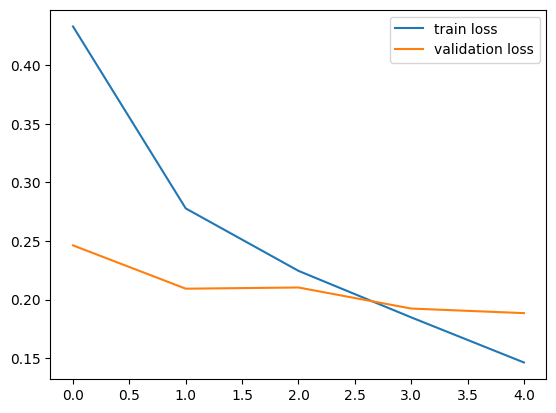

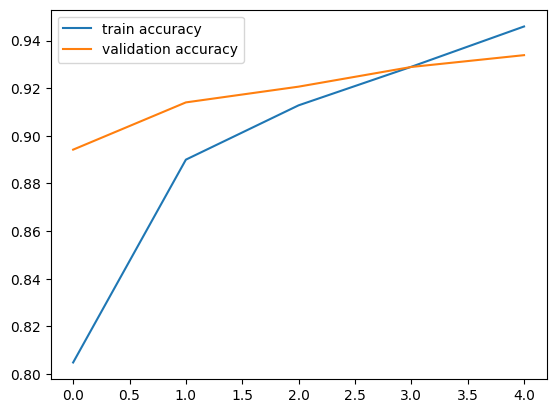

In [35]:
h = history

# plot the loss value
plt.plot(h.history['loss'], label='train loss')
plt.plot(h.history['val_loss'], label='validation loss')
plt.legend()
plt.show()

# plot the accuracy value
plt.plot(h.history['acc'], label='train accuracy')
plt.plot(h.history['val_acc'], label='validation accuracy')
plt.legend()
plt.show()

Path of the image to be predicted: /content/wtest.png


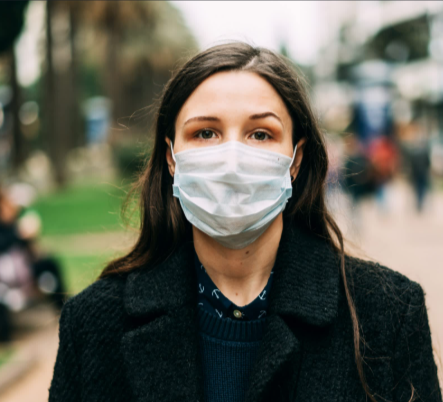

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 634ms/step
[[0.274517   0.85355943]]
1
The person in the image is wearing a mask


In [37]:
input_image_path = input('Path of the image to be predicted: ')

input_image = cv2.imread(input_image_path)

cv2_imshow(input_image)

input_image_resized = cv2.resize(input_image, (128,128))

input_image_scaled = input_image_resized/255

input_image_reshaped = np.reshape(input_image_scaled, [1,128,128,3])

input_prediction = model.predict(input_image_reshaped)

print(input_prediction)


input_pred_label = np.argmax(input_prediction)

print(input_pred_label)


if input_pred_label == 1:

  print('The person in the image is wearing a mask')

else:

  print('The person in the image is not wearing a mask')

Path of the image to be predicted: /content/witest.png


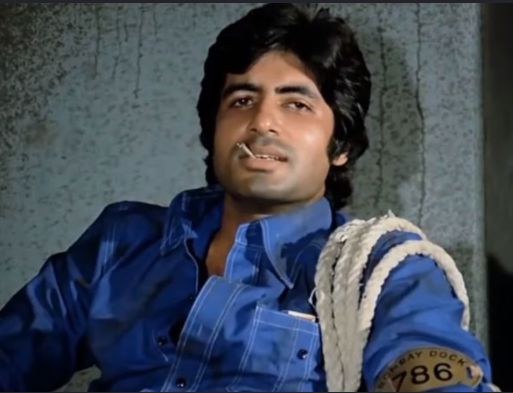

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
[[0.5513121  0.46666554]]
0
The person in the image is not wearing a mask


In [38]:
input_image_path = input('Path of the image to be predicted: ')

input_image = cv2.imread(input_image_path)

cv2_imshow(input_image)

input_image_resized = cv2.resize(input_image, (128,128))

input_image_scaled = input_image_resized/255

input_image_reshaped = np.reshape(input_image_scaled, [1,128,128,3])

input_prediction = model.predict(input_image_reshaped)

print(input_prediction)


input_pred_label = np.argmax(input_prediction)

print(input_pred_label)


if input_pred_label == 1:

  print('The person in the image is wearing a mask')

else:

  print('The person in the image is not wearing a mask')